In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import pickle

In [6]:
era5 = xr.open_zarr("/glade/derecho/scratch/yqsun/PANGU-S2S/ERA5/era5-benchX",chunks={}).rename({"lat": "latitude", "lon": "longitude", "plev":"level"})
era5['latitude'] = era5['latitude'].astype("float32")
era5['longitude'] = era5['longitude'].astype("float32")
era5['level'] = era5['level'].astype("int32")
def preprocess(ds):
    ens = np.int32(ds.encoding["source"].split("/")[-1].split(".")[0].split("_")[-1])
    ds = ds.expand_dims(dim={"number": [ens]})
    ds = ds.rename({"time":"prediction_timedelta"})
    ds = ds.expand_dims(dim={"time": [ds["prediction_timedelta"][0].values]})
    ds["prediction_timedelta"] = np.arange(0, 24*len(ds["prediction_timedelta"]), 24).astype("timedelta64[h]").astype("timedelta64[ns]")
    return ds
ds = era5["total_precipitation_24hr"]

In [6]:

def get_initialization_dates(year):
    """
    Get initialization dates (Calendar dates corresponding to 
    Mondays and Thursdays of 2024 May-July) for a given year.
    """
    # Define date range from May 1 to July 31 of 2024 (template)
    start_date = datetime.datetime(2024, 5, 1)
    end_date = datetime.datetime(2024, 7, 31)
    date_range = pd.date_range(start_date, end_date, freq='D')
    
    # Find Mondays (weekday=0) and Thursdays (weekday=3)
    is_monday = date_range.weekday == 0
    is_thursday = date_range.weekday == 3
    filtered_dates = date_range[is_monday | is_thursday]
    
    # Convert to the requested year
    filtered_dates_yr = pd.to_datetime(filtered_dates.strftime(f'{year}-%m-%d'))
    return filtered_dates_yr
years = [2019,2020,2021,2022,2023,2024]
dates_all = []
for year in years:
    dates= get_initialization_dates(year)   
    dates_all.extend(dates)
# ✅ Save to pickle
# with open("dates_all.pkl", "wb") as f:
#     pickle.dump(dates_all, f)


In [8]:
dates_all[:30]

[Timestamp('2019-05-02 00:00:00'),
 Timestamp('2019-05-06 00:00:00'),
 Timestamp('2019-05-09 00:00:00'),
 Timestamp('2019-05-13 00:00:00'),
 Timestamp('2019-05-16 00:00:00'),
 Timestamp('2019-05-20 00:00:00'),
 Timestamp('2019-05-23 00:00:00'),
 Timestamp('2019-05-27 00:00:00'),
 Timestamp('2019-05-30 00:00:00'),
 Timestamp('2019-06-03 00:00:00'),
 Timestamp('2019-06-06 00:00:00'),
 Timestamp('2019-06-10 00:00:00'),
 Timestamp('2019-06-13 00:00:00'),
 Timestamp('2019-06-17 00:00:00'),
 Timestamp('2019-06-20 00:00:00'),
 Timestamp('2019-06-24 00:00:00'),
 Timestamp('2019-06-27 00:00:00'),
 Timestamp('2019-07-01 00:00:00'),
 Timestamp('2019-07-04 00:00:00'),
 Timestamp('2019-07-08 00:00:00'),
 Timestamp('2019-07-11 00:00:00'),
 Timestamp('2019-07-15 00:00:00'),
 Timestamp('2019-07-18 00:00:00'),
 Timestamp('2019-07-22 00:00:00'),
 Timestamp('2019-07-25 00:00:00'),
 Timestamp('2019-07-29 00:00:00'),
 Timestamp('2020-05-02 00:00:00'),
 Timestamp('2020-05-06 00:00:00'),
 Timestamp('2020-05-

In [80]:
# ensemble_mean = []
# for date in date_list:
#     files = [f"/glade/campaign/univ/uchi0018/bing/predictions_stampede/pangu_plasim_2_24h_45step_{date}00_ens_{ens}.nc" for ens in range(0, 29)]
#     s2s = xr.open_mfdataset(files, chunks={}, engine='netcdf4', preprocess=preprocess)
#     var= s2s["2m_temperature"]
#     gt = era5["2m_temperature"].sel(time=(var.time + var.prediction_timedelta)) #sel(level=500)
#        #calculate ensemble mean
#     gt_area_mean = (gt).mean(dim=["time"])#, "latitude", "longitude"
#     ens_mean = var.isel(time=0).mean(dim=["number"])
#     rsme_map_ens_mean =  np.sqrt(((gt.isel(time=0) - ens_mean) ** 2).mean(dim=["latitude", "longitude"]))
#     ensemble_mean.append(rsme_map_ens_mean.values)
# np.array(ensemble_mean).shape  
# avg = np.mean(np.array(ensemble_mean),axis=0)
# np.save("ensemble_mean_ours.npy", avg)
# fuxi = np.load("ensemble_mean_fuxi.npy")

In [36]:
date = "2020072900"
files = [f"/glade/campaign/univ/uchi0018/bing/predictions_tendency/pangu_plasim_9_24h_45step_{date}_ens_{ens}.nc" for ens in range(0, 50)]
s2s = xr.open_mfdataset(files, chunks={}, engine='netcdf4', preprocess=preprocess)
variable = "2m_temperature"
var= s2s[variable]
gt = era5[variable].sel(time=(var.time + var.prediction_timedelta))
#.sel(level=500)

In [37]:
# var = var.sel(level=500)
np.sum((var.isel(prediction_timedelta=0).sel(number=0)-var.isel(prediction_timedelta=0).sel(number=1)).values)

np.float32(0.0)

In [11]:
var

<xarray.DataArray '2m_temperature' (time: 1, number: 20,
                                    prediction_timedelta: 46, latitude: 180,
                                    longitude: 360)> Size: 238MB
dask.array<concatenate, shape=(1, 20, 46, 180, 360), dtype=float32, chunksize=(1, 1, 46, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * time                  (time) datetime64[ns] 8B 2024-05-20
  * number                (number) int32 80B 0 1 2 3 4 5 6 ... 14 15 16 17 18 19
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 368B 0 days ...
  * latitude              (latitude) float32 720B -89.5 -88.5 ... 88.5 89.5
  * longitude             (longitude) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0

In [30]:
#calculate ensemble mean
idx = 0
rmse_map = np.sqrt(((gt.isel(time=idx) - var.isel(time=idx)) ** 2).mean(dim=["latitude", "longitude"]))
ens_mean = var.isel(time=idx).mean(dim=["number"])
rsme_map_ens_mean =  np.sqrt(((gt.isel(time=idx) - ens_mean) ** 2).mean(dim=["latitude", "longitude"]))

In [31]:
rsme_map_ens_mean

<xarray.DataArray '2m_temperature' (prediction_timedelta: 46)> Size: 184B
dask.array<sqrt, shape=(46,), dtype=float32, chunksize=(46,), chunktype=numpy.ndarray>
Coordinates:
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 368B 0 days ...

Figure is saved


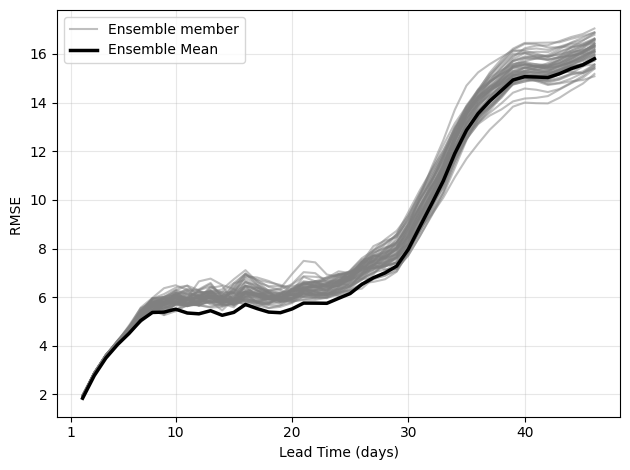

In [32]:
var_name = "t2m"
fig, ax = plt.subplots()
x = np.arange(1, 46)
rmse = []


# ---- Plot each member ----
for m in range(50):
    #member_y = rmse_map.isel(number=number).mean(dim=["latitude", "longitude"]).values[0][1:]
    member_y = rmse_map.isel(number=m).values[1:46]
    if m ==0 :
        ax.plot(x, member_y, color='gray', alpha=0.5, label="Ensemble member")
    else:
        ax.plot(x, member_y, color='gray', alpha=0.5)
    # plt.ylim(0, 8)     
    # plt.ylim(0.003, 0.01) 
    rmse.append(member_y)
rmse = np.array(rmse)

plt.xticks([0, 9, 19, 29, 39], ["1", "10", "20", "30", "40"])

# ---- Or use min–max shading instead ----
# plt.fill_between(times, rmse_min, rmse_max, alpha=0.15, label="Min–Max Range")

# ---- Plot ensemble mean ----
plt.plot(x, rsme_map_ens_mean[1:46], color='black', linewidth=2.5, label="Ensemble Mean")

plt.xlabel("Lead Time (days)")
plt.ylabel("RMSE ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.show()
plt.savefig(f"/glade/work/bgong/benchmark-dev/metrics/CRPS/{date}_{var_name}_ensemble_rmse.png", dpi=300, bbox_inches="tight")
print("Figure is saved")
plt.show()

In [34]:
np.max(gt.values)

np.float32(0.0)

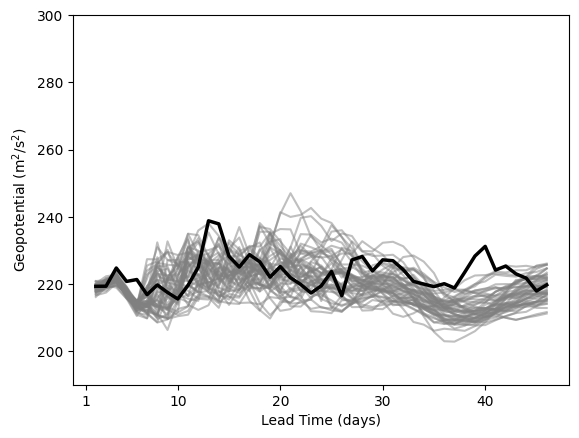

In [34]:
fig, ax = plt.subplots()
for m in range(50):
    member_y = var.isel(number=m,latitude=10,longitude=1).compute().values[0][1:46]
    ax.plot(x, member_y, color='gray', alpha=0.5)
    # plt.ylim(0, 2500) 
    # rmse.append(member_y)
    # plt.ylim(44000, 60000)
    plt.ylim(190, 300) 
    #plt.ylim(0,0.05)
gt_mem = gt.isel(latitude=10,longitude=1).compute().values[0][1:46]
ax.plot(x,gt_mem, color='black', linewidth=2.5, label="Ensemble Mean")
plt.xticks([0, 9, 19, 29, 39], ["1", "10", "20", "30", "40"])
plt.xlabel("Lead Time (days)")
plt.ylabel(r'Geopotential (m$^2$/s$^2$)')
# plt.ylabel("Temperature (K)")   # correct unit
# plt.ylabel("Total Precipitation 24hr (m)")
plt.savefig(f"/glade/work/bgong/benchmark-dev/metrics/CRPS/{date}_{var_name}_location.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
var_std = var.std(dim="number")

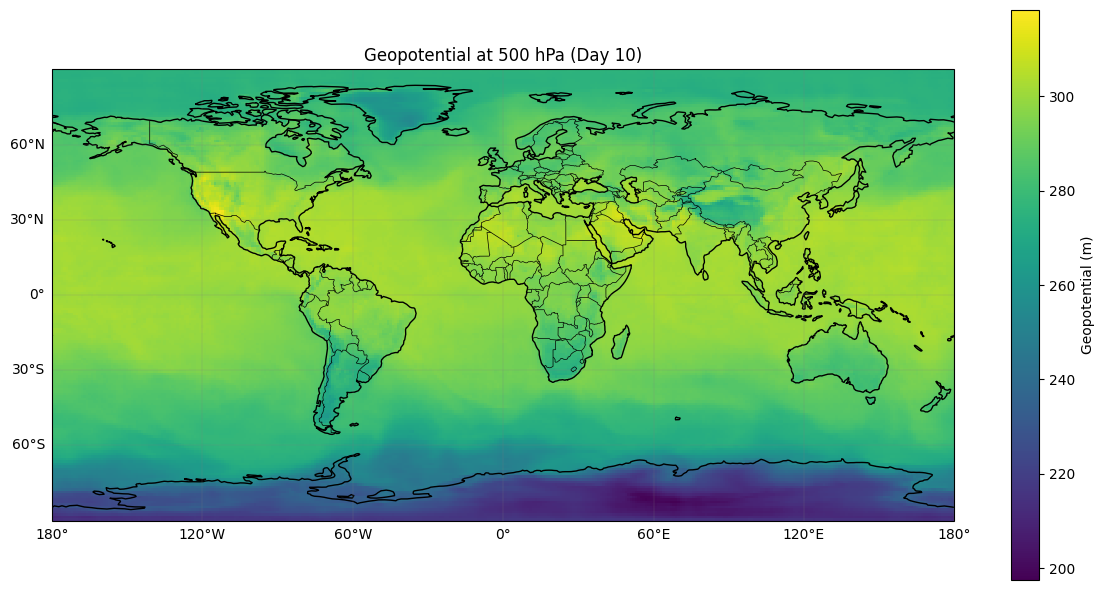

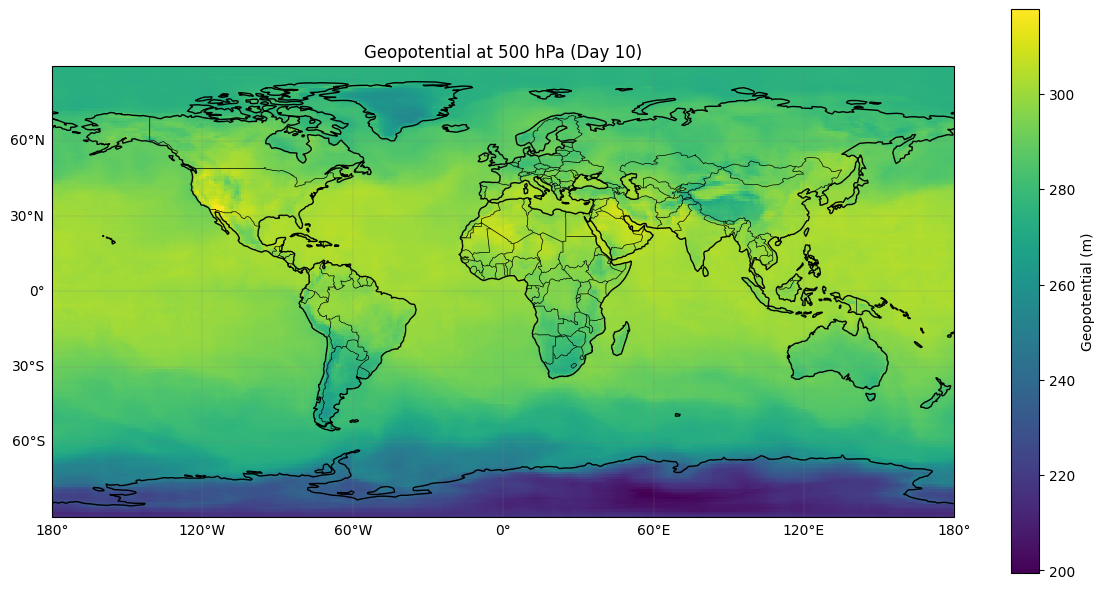

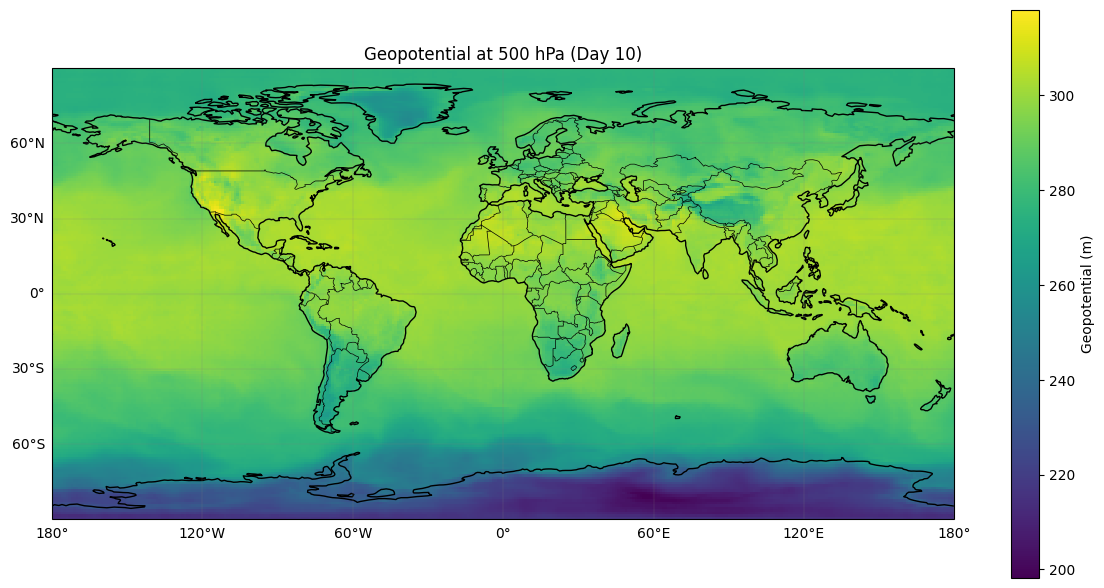

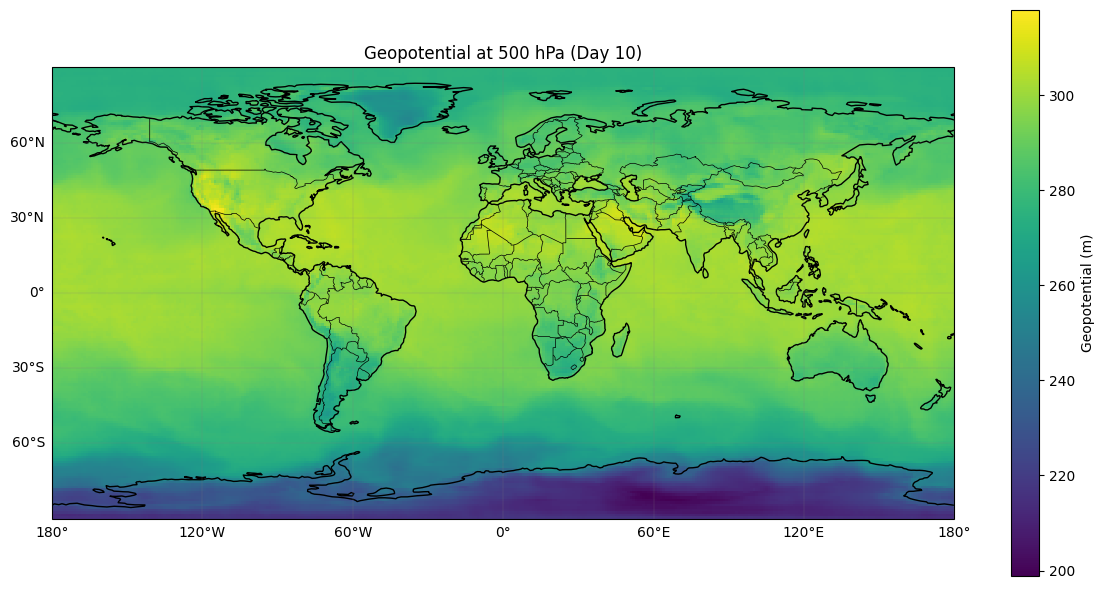

In [40]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

for mem in [0,1,10,15]:
    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw=dict(projection=ccrs.PlateCarree()))

    # Plot the forecast field (ensemble mean)
    ens_mean_field = var.isel(prediction_timedelta=1).sel(number=mem)
    #-var.isel(prediction_timedelta=0).sel(number=mem)
    im = ens_mean_field.plot(
        ax=ax,
        # vmin = -4000,
        # vmax = 6000,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        add_colorbar=True,
        cbar_kwargs={"label": "Geopotential (m)"}
    )

    # Add coastlines and geographic features
    ax.coastlines(resolution="110m", linewidth=1, color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.2)

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    plt.title("Geopotential at 500 hPa (Day 10)")
    plt.tight_layout()
    plt.savefig(f"/glade/work/bgong/benchmark-dev/metrics/CRPS/forecast_day1_coastline_mem{mem}.png", dpi=300, bbox_inches="tight")
    plt.show()

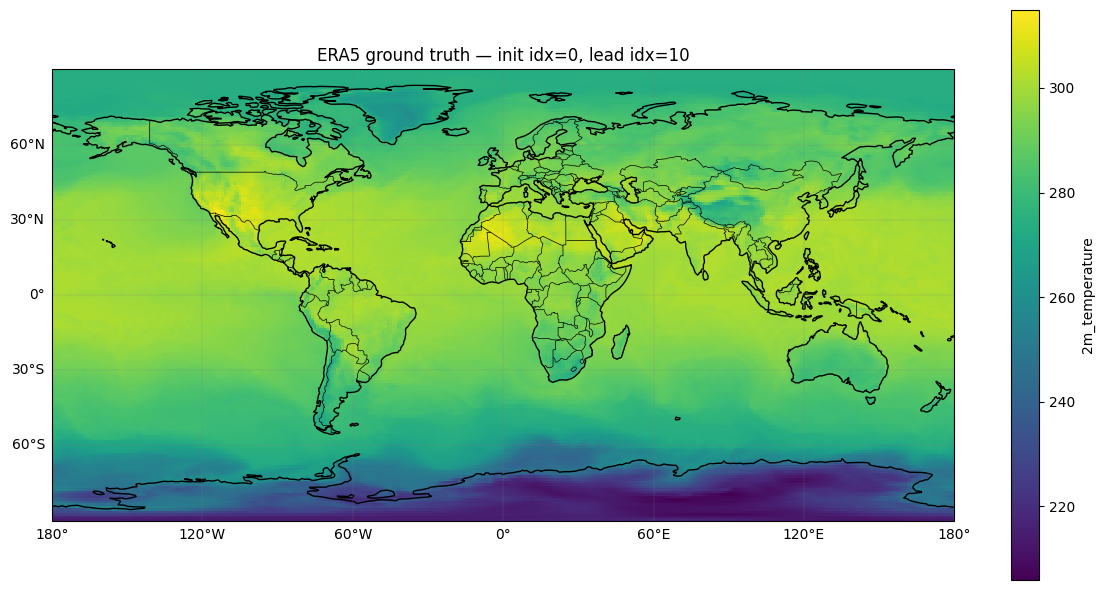

In [41]:

# select the same lead as your forecast plots
prediction_idx = 10   # adjust to the lead-time index you plotted for forecasts
time_idx = 0          # initialization index (change if you want a different init)

# ground truth field (ERA5) -- gt was created earlier as era5[...] aligned with var
gt_field = gt.isel(time=time_idx, prediction_timedelta=prediction_idx)

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw=dict(projection=ccrs.PlateCarree()))
im = gt_field.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    add_colorbar=True,
    cbar_kwargs={"label": variable}
)

ax.coastlines(resolution="110m", linewidth=1, color="black")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.2)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.title(f"ERA5 ground truth — init idx={time_idx}, lead idx={prediction_idx}")
plt.tight_layout()
plt.savefig(f"/glade/work/bgong/benchmark-dev/metrics/CRPS/{date}_gt_init{time_idx}_lead{prediction_idx}.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
# var_std.isel(prediction_timedelta=45).plot(figsize=(10, 6),vmin=0,vmax=0.04)
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw=dict(projection=ccrs.PlateCarree()))
# plot with explicit transform so Cartopy can place it correctly
im = var.isel(prediction_timedelta=10).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    # cmap="viridis",
    add_colorbar=True,
    cbar_kwargs={"label": "Std (units)"}
)

# add coastlines and optional features
ax.coastlines(resolution="110m", linewidth=1, color="black")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.2)

# gridlines and labels
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.title(f"10 Day")
plt.tight_layout()

plt.show()

AttributeError: Rectangle.set() got an unexpected keyword argument 'add_colorbar'

In [54]:
file = "/glade/work/bgong/pangu_plasim_14_24h_1step_2018010100_ens_2.nc"

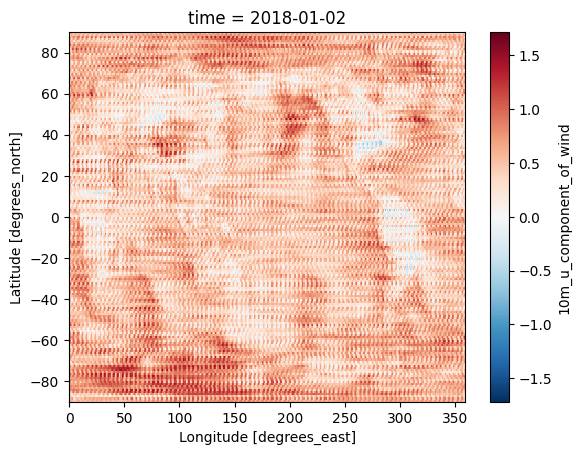

In [67]:
dt = xr.open_dataset(file)
dt["10m_u_component_of_wind"].isel(time=1).plot()

In [62]:
dt

<xarray.Dataset> Size: 50MB
Dimensions:                                (time: 2, level: 17, latitude: 180,
                                            longitude: 360)
Coordinates:
  * time                                   (time) datetime64[ns] 16B 2018-01-...
  * level                                  (level) float32 68B 5.0 ... 1e+03
  * latitude                               (latitude) float32 720B -89.5 ... ...
  * longitude                              (longitude) float32 1kB 0.0 ... 359.0
Data variables: (12/16)
    2m_temperature                         (time, latitude, longitude) float32 518kB ...
    10m_u_component_of_wind                (time, latitude, longitude) float32 518kB ...
    10m_v_component_of_wind                (time, latitude, longitude) float32 518kB ...
    mean_sea_level_pressure                (time, latitude, longitude) float32 518kB ...
    surface_pressure                       (time, latitude, longitude) float32 518kB ...
    volumetric_soil_water_layer_1          (time, latitude, longitude) float32 518kB ...
    ...                                     ...
    u_component_of_wind                    (time, level, latitude, longitude) float32 9MB ...
    v_component_of_wind                    (time, level, latitude, longitude) float32 9MB ...
    specific_humidity                      (time, level, latitude, longitude) float32 9MB ...
    geopotential                           (time, level, latitude, longitude) float32 9MB ...
    total_precipitation_24hr               (time, latitude, longitude) float32 518kB ...
    mean_top_net_long_wave_radiation_flux  (time, latitude, longitude) float32 518kB ...
Attributes:
    description:  Prediction from pangu_plasim model run 14

(array([ 83247., 118428., 170271., 204388., 156099., 100413.,  74594.,
         81697., 100416.,  12047.]),
 array([-1.87273359, -0.16807075,  1.53659213,  3.24125504,  4.94591761,
         6.65058041,  8.35524368, 10.05990601, 11.76456928, 13.46923161,
        15.17389488]),
 <BarContainer object of 10 artists>)

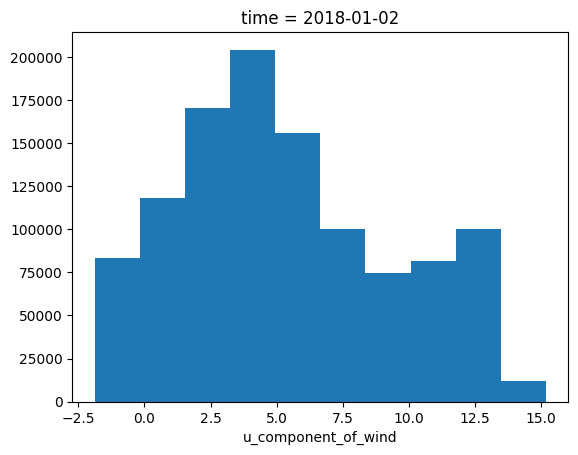

In [61]:
dt["u_component_of_wind"].isel(time=1).plot()

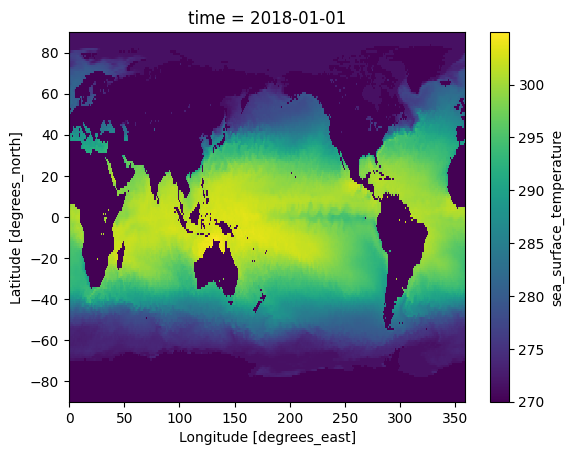

In [60]:
dt["sea_surface_temperature"].isel(time=0).plot()

In [ ]:
dt["g"].isel(time=1).plot()